# Étape 2 — Agent DDPG pour la gestion de stock

Ce notebook entraîne l'agent DDPG (`agent/ddpg.py`) sur l'environnement d'inventaire
(`env/inventory_env.py`), construit à partir du dataset Kaggle *Retail Store Inventory
Forecasting Dataset*.

**Rappel du principe :**
- État (2 dimensions), conformément à l'analyse de corrélation de
  `01_exploration.ipynb` : niveau de stock, demande prévue.
- Action (1 dimension continue) : quantité à commander, bornée dans `[0, MAX_ORDER]`.
- Récompense (Newsvendor Problem) : profit journalier = cp * ventes − ch * stock
  restant − cp * ventes perdues, avec cp = prix du produit et ch = 20% de cp.
- Un épisode = une fenêtre de 365 jours (tirée aléatoirement dans la série disponible)
  d'un couple (magasin, produit) tiré aléatoirement à chaque `reset()`.

In [1]:
import sys
sys.path.append("..")  

import numpy as np
import torch
import matplotlib.pyplot as plt

from agent.ddpg import DDPGAgent
from env.inventory_env import InventoryEnv
from utils import plot_training_curve

DATA_PATH = "../data/retail_store_inventory.csv"
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "c:\Users\skabo\anaconda4\lib\runpy.py", line 196, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "c:\Users\skabo\anaconda4\lib\runpy.py", line 86, in _run_code
    exec(code, run_globals)
  File "c:\Users\skabo\anaconda4\lib\site-packages\ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "c:\Users\skabo\anaconda4\lib\site-packages\traitlets\config\application.py", line 1075, in launch_instance
    app.start()
  File "c:\Users\skabo\anaconda4\lib\site-pac

AttributeError: _ARRAY_API not found

## 1. Initialisation de l'environnement et de l'agent

In [2]:
env = InventoryEnv(DATA_PATH)  

agent = DDPGAgent(
    state_dim=env.state_dim,
    action_dim=env.action_dim,
    action_low=env.action_low,
    action_high=env.action_high,
    actor_lr=1e-4,
    critic_lr=1e-3,
    gamma=0.99,
    tau=0.005,
)

print("state_dim :", env.state_dim)
print("action bounds :", env.action_low, "->", env.action_high)

state_dim : 2
action bounds : 0.0 -> 300.0


## 2. Boucle d'entraînement

In [3]:
N_EPISODES = 1000
WARMUP_STEPS = 500
BATCH_SIZE = 128

total_steps = 0
episode_rewards = []

for episode in range(1, N_EPISODES + 1):
    state = env.reset(seed=SEED + episode)
    agent.noise.reset()
    ep_reward = 0.0
    done = False

    while not done:
        if total_steps < WARMUP_STEPS:
            action = np.random.uniform(env.action_low, env.action_high, size=(env.action_dim,))
        else:
            action = agent.select_action(state, explore=True)

        next_state, reward, done, info = env.step(action)
        agent.store_transition(state, action, reward, next_state, float(done))

        if total_steps >= WARMUP_STEPS:
            agent.update(batch_size=BATCH_SIZE)

        state = next_state
        ep_reward += reward
        total_steps += 1

    episode_rewards.append(ep_reward)
    if episode % 5 == 0 or episode == 1:
        print(f"Épisode {episode:3d}/{N_EPISODES} | récompense = {ep_reward:8.2f} | "
              f"moyenne (5 derniers) = {np.mean(episode_rewards[-5:]):8.2f}")

Épisode   1/500 | récompense =   312.39 | moyenne (5 derniers) =   312.39
Épisode   5/500 | récompense =  1079.24 | moyenne (5 derniers) =  -293.27
Épisode  10/500 | récompense =   965.09 | moyenne (5 derniers) =  1686.55
Épisode  15/500 | récompense =  2192.83 | moyenne (5 derniers) =  1723.51
Épisode  20/500 | récompense =  2403.48 | moyenne (5 derniers) =  2281.56
Épisode  25/500 | récompense =  2183.81 | moyenne (5 derniers) =  2373.53
Épisode  30/500 | récompense =  2419.77 | moyenne (5 derniers) =  2336.50
Épisode  35/500 | récompense =  2294.39 | moyenne (5 derniers) =  2147.65
Épisode  40/500 | récompense =  1947.37 | moyenne (5 derniers) =  2222.43
Épisode  45/500 | récompense =  2223.11 | moyenne (5 derniers) =  2316.23
Épisode  50/500 | récompense =  2449.86 | moyenne (5 derniers) =  2370.66
Épisode  55/500 | récompense =  2489.72 | moyenne (5 derniers) =  2411.19
Épisode  60/500 | récompense =  2502.76 | moyenne (5 derniers) =  2362.40
Épisode  65/500 | récompense =  2200.7

## 3. Courbe d'apprentissage

Courbe sauvegardée : ../results/plots/training_curve_notebook.png


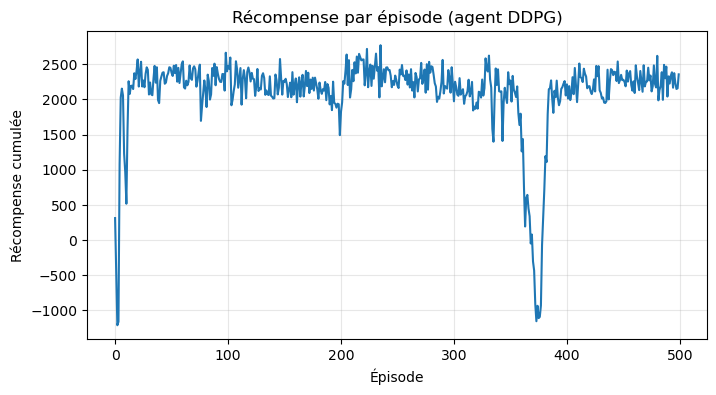

In [8]:
plot_training_curve(episode_rewards, save_path="../results/plots/training_curve_notebook.png", window=5)

plt.figure(figsize=(8, 4))
plt.plot(episode_rewards)
plt.xlabel("Épisode")
plt.ylabel("Récompense cumulée")
plt.title("Récompense par épisode (agent DDPG)")
plt.grid(alpha=0.3)
plt.show()

## 4. Sauvegarde du modèle entraîné

In [9]:
import os
os.makedirs("../results/models", exist_ok=True)
agent.save("../results/models/ddpg_notebook")
print("Modèle sauvegardé dans results/models/")

Modèle sauvegardé dans results/models/


## 5. Inspection d'un épisode (politique apprise vs. demande réelle)

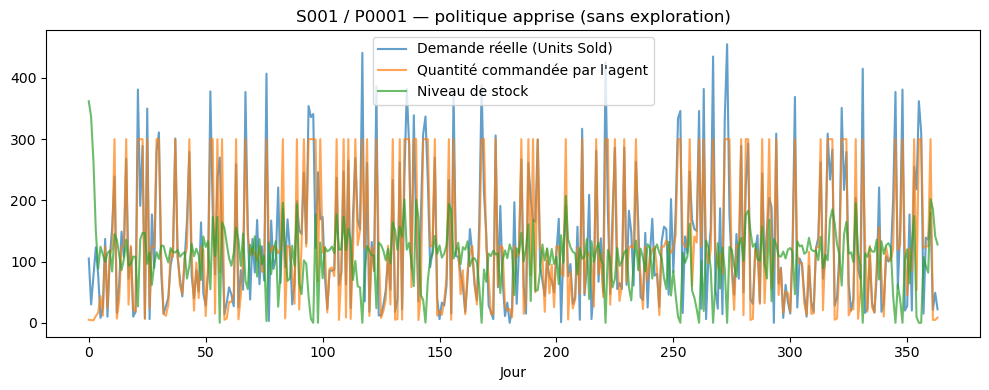

In [10]:
eval_env = InventoryEnv(DATA_PATH, store_id="S001", product_id="P0001")
state = eval_env.reset(seed=0)

orders, demands, inventories = [], [], []
done = False
while not done:
    action = agent.select_action(state, explore=False)
    state, reward, done, info = eval_env.step(action)
    orders.append(info["order"])
    demands.append(info["demand"])
    inventories.append(info["inventory"])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(demands, label="Demande réelle (Units Sold)", alpha=0.7)
ax.plot(orders, label="Quantité commandée par l'agent", alpha=0.7)
ax.plot(inventories, label="Niveau de stock", alpha=0.7)
ax.set_xlabel("Jour")
ax.legend()
ax.set_title("S001 / P0001 — politique apprise (sans exploration)")
plt.tight_layout()
plt.show()